Exploração e limpeza de dados utilizando os dados de uma planilha em excel contendo os dados de clientes de um banco Taiwanês

Objetivo: Desenvolver um modelo para prever se uma conta ficará inadimplente no próximo mês com base nos dados demográficos e históricos.

Referências:

Cápitulo 01 - Livro Projetos de Ciência de Dados com Python (Abordagem de estudo de caso para a criação de projetos de ciência de dados bem-sucedidos usando Python, pandas e scikit-learn)

Utilizei o dicionário de dados disponível em https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

Etapas para Análise e exploração de dados:

1 - Saber quantas colunas os dados tem

2 - Quantas linhas há

3 - Que tipos de características existem. Quais são categóricas e quais são numéricas?

4 - Qual é a aparência dos dados estão extraídos corretamente?

5 - Há dados faltantes?

6 - Entender qual a utilidade destes dados para empresa e quais são as regras de negócio

# Exercício 2: Carregando o banco de dados no Jupyter Notebook

In [2]:
# Carregando as bibliotecas que serão utilizadas
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import sklearn

In [3]:
#Iremos utilizar a biblioteca pandas para realizar a importação dos dados
import pandas as pd

Estes dados do arquivo xls serão armazenados na váriavel df

In [7]:
df = pd.read_excel('/home/livia/Documentos/Ambientes/default_of_credit_card_clients.xls')

In [8]:
#Exibe o formato da base de dados que possui 30000 linhas e 25 colunas
df.shape

(30000, 25)

# Exercício 3: Verificando a integridade dos dados

Iremos realizar verificações básicas a fim de verificar se o dataset contém os valores esperados e examinaremos o número correto de amostras

Os dados devem ter informações referentes a 30.000 contas de crédito. Portanto devemos verificar se as 30.000 linhas correspondem a IDs exclusivos

Para realizar a analise podemos verificar se o númeero de IDs de contas exclusivos é igual ao número de linhas

In [9]:
#Examinando o número de colunas
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

Colunas do Banco de dados

1 - LIMIT_BAL: valor do crédito fornecido, inclusive o crédito complementar fornecido ao consumidor individual e a família (em novos dólares taiwaneses(NT))

2- SEX: Gênero (1= masculino, 2= feminino) Não será utilizado

3- EDUCATION: Nível de instrução academica (1 = Pós graduação, 2 = Graduação universidade, 3 = Ensino médio, 4 = outros)

4- MARRIAGE: Estado cívil (1 = casado, 2 = solteiro, 3 = outros)

5- AGE (idade)

6- PAY_1 - PAY_6: Registro de pagamentos passados. Pagamentos mensais passados, registrados de abril a setembro

7- PAY_AMT1 - PAY_AMT6: Registro de pagamentos anteriores

8- BILL_AMT1 - BILL_AMT6: Valor das faturas, registrados de abril a setembro

In [10]:
#Exibe as 5 primeiras linhas do dataset
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [11]:
#Exibe quantidade de linhas e colunas
df.shape

(30000, 25)

In [12]:
#Examinando a coluna ID, exibindo os valores unicos com o método 'Nunique'
df['ID'].nunique()

29687

Nunique retorna o total de valores únicos da coluna ID

Observamos que há menos valores exclusívos do que colunas, ficando evidente que há dados duplicados, precisamos analisar como ela ocorre.

Como os IDs estão sendo duplicados?

Para isso iremos criar uma variavel que irá contar quantos valores estão armazenados em 'ID'

In [13]:
id_counts = df['ID'].value_counts()
id_counts.head()

ID
26bde6da-f148    2
42009c72-651f    2
73ed1381-3a3f    2
4f95b36b-ab10    2
8d3a2576-a958    2
Name: count, dtype: int64

In [14]:
#Retorna os valores que aparecem uma vez e os que estão duplicados
id_counts.value_counts()

count
1    29374
2      313
Name: count, dtype: int64

Há 313 valores dupplicados, nenhum ID aparece mais do que duas vezes

Iremos criar uma máscara booleana para limpar os dados

# Máscaras booleanas ou lógicas

Uma máscara booleana ou máscara lógica é uma maneira de filtrar um array ou série obedecendo uma condição. A saída da operação será True quando ela obedece a condição e False quando não obedece

# Exercício 4: Verificação de dados e Aplicação da máscara booleana

In [15]:
#Criando uma variável dupe_mask para armazenar os valores booleanos
dupe_mask = id_counts == 2

In [16]:
dupe_mask[0:5]

ID
26bde6da-f148    True
42009c72-651f    True
73ed1381-3a3f    True
4f95b36b-ab10    True
8d3a2576-a958    True
Name: count, dtype: bool

In [17]:
type(dupe_mask)

pandas.Series

In [18]:
#Exibindo as cinco primeiras linhas
id_counts.index[0:5]

Index(['26bde6da-f148', '42009c72-651f', '73ed1381-3a3f', '4f95b36b-ab10',
       '8d3a2576-a958'],
      dtype='str', name='ID')

In [19]:
#Selecionando e armazenando os Ids duplicados na variável dupe_ids
dupe_ids = id_counts.index[dupe_mask]

In [20]:
#Convertendo a variável para lista
dupe_ids = list(dupe_ids)
len(dupe_ids)

313

In [21]:
dupe_ids[0:5]

['26bde6da-f148',
 '42009c72-651f',
 '73ed1381-3a3f',
 '4f95b36b-ab10',
 '8d3a2576-a958']

Iremos armazenar os dados das características da coluna ID, se houver algo de diferente podemos consertar com base neles.

Usando os três primeiros IDs da lista de duplicatas dupe_ids[0:3]

Iremos passar essa lista para o método .isin da série ID, para criar outra máscara booleana. Este método ficará alinhado em uma instrução .loc de indexação do dataframe, para a seleção do local de todas as linhas que possui True como resultado

Ao executar a linha de código iremos criar um filtro que exibirá apenas as linhas em que aparecem os IDs duplicados

In [22]:
df.loc[df['ID'].isin(dupe_ids[0:3]),:].head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
141,26bde6da-f148,180000,1,2,2,28,-1,-1,-1,-1,...,332,416,416,0,416,332,500,3500,832,0
196,42009c72-651f,150000,2,2,1,34,-2,-2,-2,-2,...,116,0,1500,0,0,116,0,1500,0,0
241,26bde6da-f148,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
296,42009c72-651f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
323,73ed1381-3a3f,230000,2,2,1,28,0,0,0,-2,...,2100,767,6173,1710,1100,1000,767,6173,1000,1
423,73ed1381-3a3f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Observamos em que as linhas dos IDs duplicados possuem valores somente com 0

A solução elaborada será: realizar a exclusão somente das colunas duplicadas que possuem valores igual a '0', permanecendo as colunas com valores normalizados

In [23]:
#Iremos criar uma máscara booleana que irá armazenar os valores do dataset que são iguais a '0'
df_zero_mask = df == 0

In [24]:
#Considera todas as colunas com valores iguais a '0' e retorna como verdadeiro quando ela esse valor aparece
feature_zero_mask = df_zero_mask.iloc[:,1:].all(axis=1)

In [25]:
#Relaiza a soma de todas as features que tem valor '0'
sum(feature_zero_mask)

315

Iremos criar um novo dataset e realizar a limpeza dos dados duplicados armazenando na variável somente as linhas em que os valores não são iguais a zero

In [26]:
df_clean_1 = df.loc[~feature_zero_mask,:].copy()

In [27]:
df_clean_1.shape

(29685, 25)

In [28]:
#Teste para exibir se funcionou
df_clean_1['ID'].nunique()

29685

Foram exibidos 29685 linhas exclusívas, indicando que houve a exclusão das 313 linhas duplicadas

29685 + 313 = 30000 linhas inicias

# Exercício 5: Explorando e limpando dados

In [29]:
#Verificando as informações do dataset
df_clean_1.info()

<class 'pandas.DataFrame'>
Index: 29685 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29685 non-null  str   
 1   LIMIT_BAL                   29685 non-null  int64 
 2   SEX                         29685 non-null  int64 
 3   EDUCATION                   29685 non-null  int64 
 4   MARRIAGE                    29685 non-null  int64 
 5   AGE                         29685 non-null  int64 
 6   PAY_1                       29685 non-null  object
 7   PAY_2                       29685 non-null  int64 
 8   PAY_3                       29685 non-null  int64 
 9   PAY_4                       29685 non-null  int64 
 10  PAY_5                       29685 non-null  int64 
 11  PAY_6                       29685 non-null  int64 
 12  BILL_AMT1                   29685 non-null  int64 
 13  BILL_AMT2                   29685 non-null  int64 
 14  BILL_A

Observamos que as colunas não possuem dados com valores nulos, no entanto se estes dados estiverem representados de uma forma que foge do padrão devemos realizar as devidas correções

Iremos analisar a coluna PAY_1 que armazena as informações de registro de pagamento do mẽs de setembro

In [30]:
df_clean_1['PAY_1'].head(5)

0     2
1    -1
2     0
3     0
4    -1
Name: PAY_1, dtype: object

In [31]:
#Obtendo a contagem de valores da coluna PAY_1  usando o método .value_counts()
df_clean_1['PAY_1'].value_counts()

PAY_1
0                13087
-1                5047
1                 3261
Not available     3021
-2                2476
2                 2378
3                  292
4                   63
5                   23
8                   17
6                   11
7                    9
Name: count, dtype: int64

Observamos a presença de valores ausentes 'Not Available' e a presença de dois valores que não aparecem no dicionário de dados 0, -2

In [32]:
#Utilizaremos uma máscara lógica com o operador != "diferente de", para exibir todas as linhas que não possuem dados ausentes para as features de PAY_1
valid_pay_1_mask = df_clean_1['PAY_1'] != 'Not available'

In [33]:
valid_pay_1_mask[0:5]

0    True
1    True
2    True
3    True
4    True
Name: PAY_1, dtype: bool

In [34]:
#Soma das linhas que não tem dados ausentes
sum(valid_pay_1_mask)

26664

Observamos que 26664 linhas não têm valores 'Not Available'

Na contagem 3021 linhas tinham esse valor se 3021 - 29685 = 26664 então este resultado está correto

In [35]:
#Iremos eliminar as linhas com valores ausentes de PAY_1 e realizar uma cópia do dataset armazenada na variável df_clean_2
df_clean_2 = df_clean_1.loc[valid_pay_1_mask,:].copy()

In [36]:
df_clean_2.shape

(26664, 25)

In [37]:
df_clean_2['PAY_1'].value_counts()

PAY_1
0     13087
-1     5047
1      3261
-2     2476
2      2378
3       292
4        63
5        23
8        17
6        11
7         9
Name: count, dtype: int64

In [38]:
df_clean_2['PAY_1'] = df_clean_2['PAY_1'].astype('int64')

In [39]:
df_clean_2[['PAY_1', 'PAY_2']].info()

<class 'pandas.DataFrame'>
Index: 26664 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   PAY_1   26664 non-null  int64
 1   PAY_2   26664 non-null  int64
dtypes: int64(2)
memory usage: 624.9 KB


Os dados forma limpos da maneira correta

# Exercício 6: Explorando o limite de crédito e as características demográficas

In [40]:
import matplotlib.pyplot as plt #importando o pacote para utilização na visualização de gráficos

#automatizando a renderizazção da plotagem
%matplotlib inline

import matplotlib as mpl #recurso adicional de plotagem

mpl.rcParams['figure.dpi'] = 400 #figuras em alta dimensão

array([[<Axes: title={'center': 'LIMIT_BAL'}>,
        <Axes: title={'center': 'AGE'}>]], dtype=object)

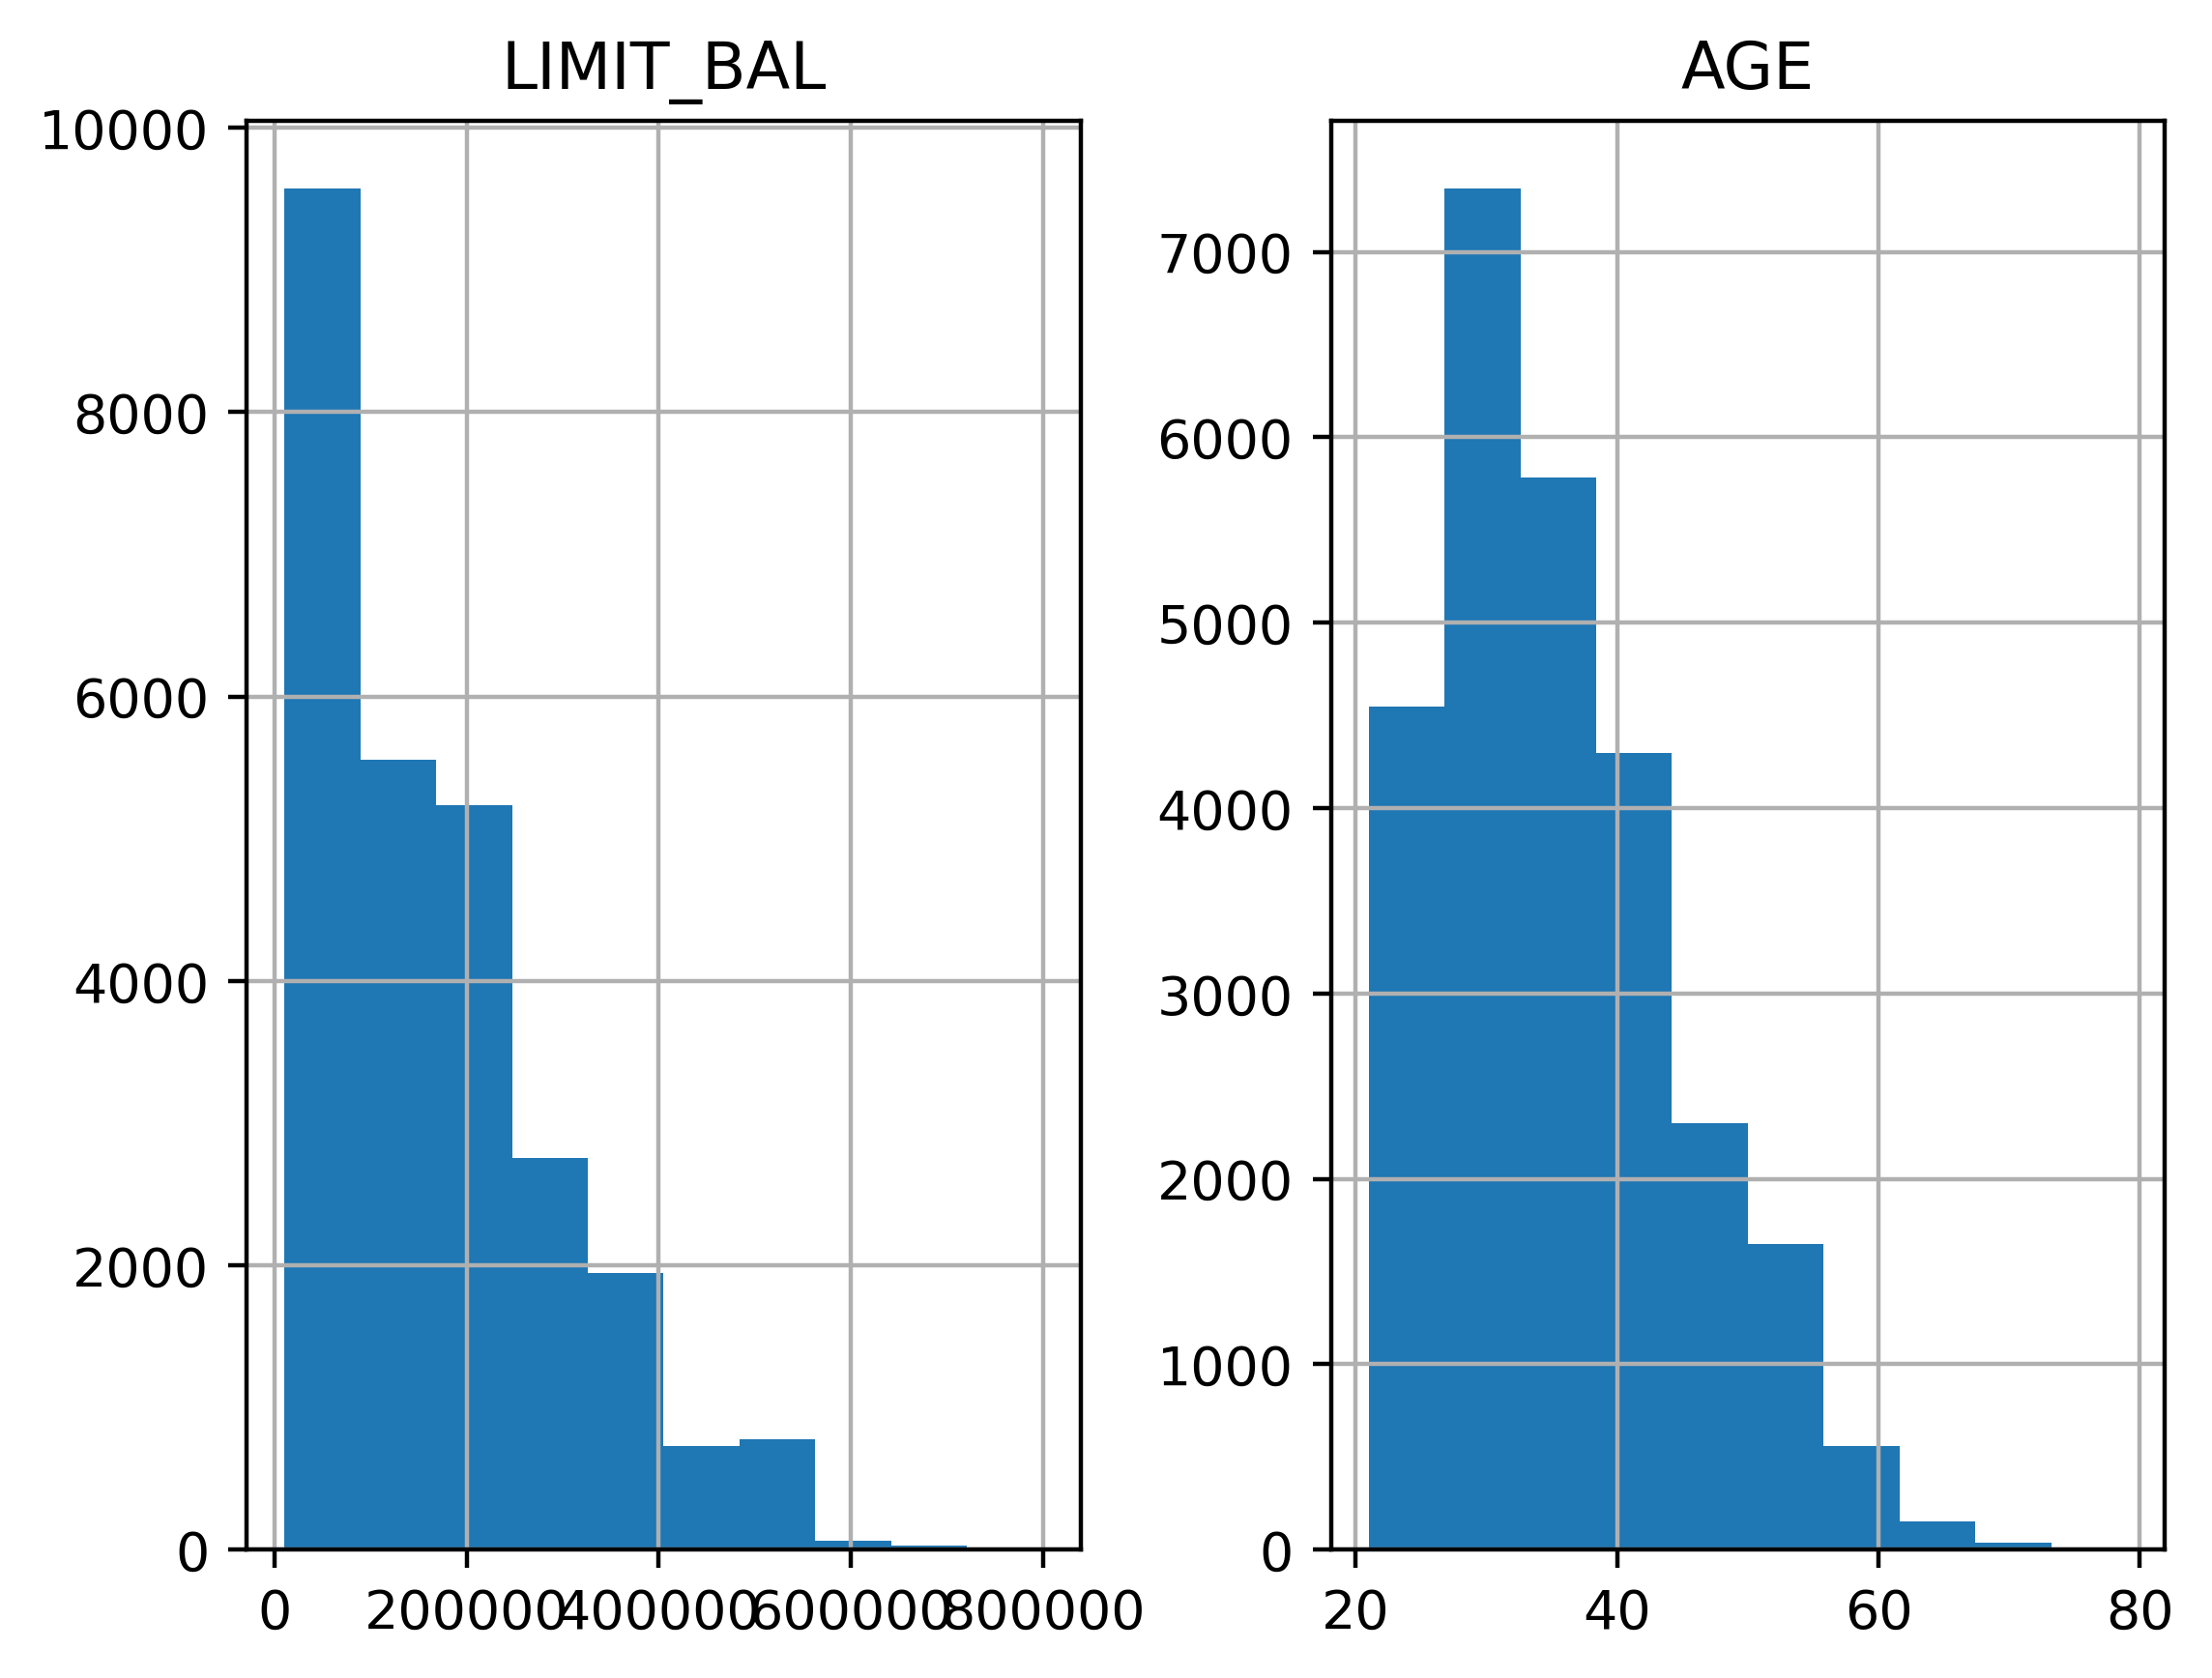

In [41]:
#Exibindo os histogramas referentes as colunas LIMIT_BAL e AGE
df_clean_2[['LIMIT_BAL', 'AGE']].hist()

In [42]:
#Exibindo um relatório tabular com a descrição das características das colunas
df_clean_2[['LIMIT_BAL', 'AGE']].describe()

,LIMIT_BAL,AGE
count,26664.000000,26664.000000
mean,167919.054905,35.505213
std,129839.453081,9.227442
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,800000.000000,79.000000


Limites de crédito parecem fazer sentido tendo um valor mínimo de 10000, sendo este dataset de Taiwan onde a moeda são os novos dólares Taiwaneses, portando devemos levar em conta que o limite de crédito deve ser acima de zero e a idade mínima dos clientes maior que 21 anos.

Iremos realizar as contagens de valores dos dados categóricos da característica EDUCATION

In [43]:
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
5      245
4      115
6       43
0       11
Name: count, dtype: int64

"Education (1 = pós graduação; 2 = graduação; 3 = ensino médio; 4 = outros)"
Iremos inserir os dados de 0, 5 e 6 na categoria outros

In [44]:
df_clean_2['EDUCATION'] = df_clean_2['EDUCATION'].replace([0,5,6],4)

In [45]:
#Conferindo se os dados foram realocados corretamente
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
4      414
Name: count, dtype: int64

Examinandos os dados categóricos da coluna MARRIAGE

Onde deve haver somente (1 = casado; 2 = solteiro; 3 = outros)

In [46]:
df_clean_2['MARRIAGE'].value_counts()

MARRIAGE
2    14158
1    12172
3      286
0       48
Name: count, dtype: int64

Devemos realocar os valores de 0 para 3 que representa outros

In [47]:
df_clean_2['MARRIAGE'] = df_clean_2['MARRIAGE'].replace([0],3)

In [48]:
#Verificando se os dados foram realocados
df_clean_2['MARRIAGE'].value_counts()

MARRIAGE
2    14158
1    12172
3      334
Name: count, dtype: int64

# Exercício 7: Implementando a One HHot encoding para uma característica categórica

One Hot Encoding consiste em um método utilizado para transformar uma característica categórica em uma característica numérica

Iremos implementar engenharia reversa na coluna EDUCATION a fim de obter rótulos de textro para representar diferenes graus de instrução e criaremos uma OHE com Pandas

In [49]:
df_clean_2['EDUCATION'].head()

0    2
1    2
2    2
3    2
4    2
Name: EDUCATION, dtype: int64

In [50]:
#Criando uma coluna vazia para os rótulos categóricos chamada EDUCATION_CAT
df_clean_2['EDUCATION_CAT'] = 'none'

In [51]:
#Examinando as primeiras linhas do dataframe
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10)

,EDUCATION,EDUCATION_CAT
0,2,none
1,2,none
2,2,none
3,2,none
4,2,none
5,1,none
6,1,none
7,2,none
8,3,none
9,3,none


In [52]:
#Iremos criar um dicionário para armazenar cada categoria
cat_mapping = {
    1: "graduate school",
    2: "university",
    3: "high school",
    4: "others"
}

In [53]:
#Atribuindo o mapeamento da coluna EDUCATION original usnado .map e atribuindo o resultado a nova coluna EDUCATION_CAT
df_clean_2['EDUCATION_CAT'] = df_clean_2['EDUCATION'].map(cat_mapping)

In [54]:
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10)

,EDUCATION,EDUCATION_CAT
0,2,university
1,2,university
2,2,university
3,2,university
4,2,university
5,1,graduate school
6,1,graduate school
7,2,university
8,3,high school
9,3,high school


In [55]:
#Iremos criar uma variável edu_ohe para armazenar o dataframe com a aplicação do OHE
edu_ohe = pd.get_dummies(df_clean_2['EDUCATION_CAT'])
edu_ohe.head(10)

,graduate school,high school,others,university
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True
5,True,False,False,False
6,True,False,False,False
7,False,False,False,True
8,False,True,False,False
9,False,True,False,False


In [56]:
#Iremos salvar a cópia do dataframe na variável df_with_ohe
df_with_ohe = pd.concat([df_clean_2, edu_ohe], axis=1)
df_with_ohe[['EDUCATION_CAT', 'graduate school',
             'high school', 'university', 'others']].head(10)

,EDUCATION_CAT,graduate school,high school,university,others
0,university,False,False,True,False
1,university,False,False,True,False
2,university,False,False,True,False
3,university,False,False,True,False
4,university,False,False,True,False
5,graduate school,True,False,False,False
6,graduate school,True,False,False,False
7,university,False,False,True,False
8,high school,False,True,False,False
9,high school,False,True,False,False


In [57]:
#Salvando o projeto
df = df_with_ohe.to_csv('/home/livia/PyCharmMiscProject/df_with_ohe.csv', index=False)

In [58]:
df = df_with_ohe

In [59]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'EDUCATION_CAT', 'graduate school',
       'high school', 'others', 'university'],
      dtype='str')

In [60]:
df.shape

(26664, 30)

# Explorando as características do histórico financeiro do dataset
Iremos analisar os dados das colunas PAY_1 a PAY_6 que armazenam o histórico de pagamentos do mês de abril a setembro

In [61]:
#Iremos armazenar as seis colunas em uma só variável
pay_feats = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [62]:
#Exibe as características das colunas
df[pay_feats].describe()

,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,-0.017777,-0.133363,-0.167679,-0.225023,-0.269764,-0.293579
std,1.126769,1.198640,1.199165,1.167897,1.131735,1.150229
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


In [63]:
#Seleciona o primeiro indice da lista, a coluna PAY_1 com dados de Setembro
df[pay_feats[0]].value_counts().sort_index()

PAY_1
-2     2476
-1     5047
 0    13087
 1     3261
 2     2378
 3      292
 4       63
 5       23
 6       11
 7        9
 8       17
Name: count, dtype: int64

In [64]:
pay_feats[0]

'PAY_1'

<Axes: >

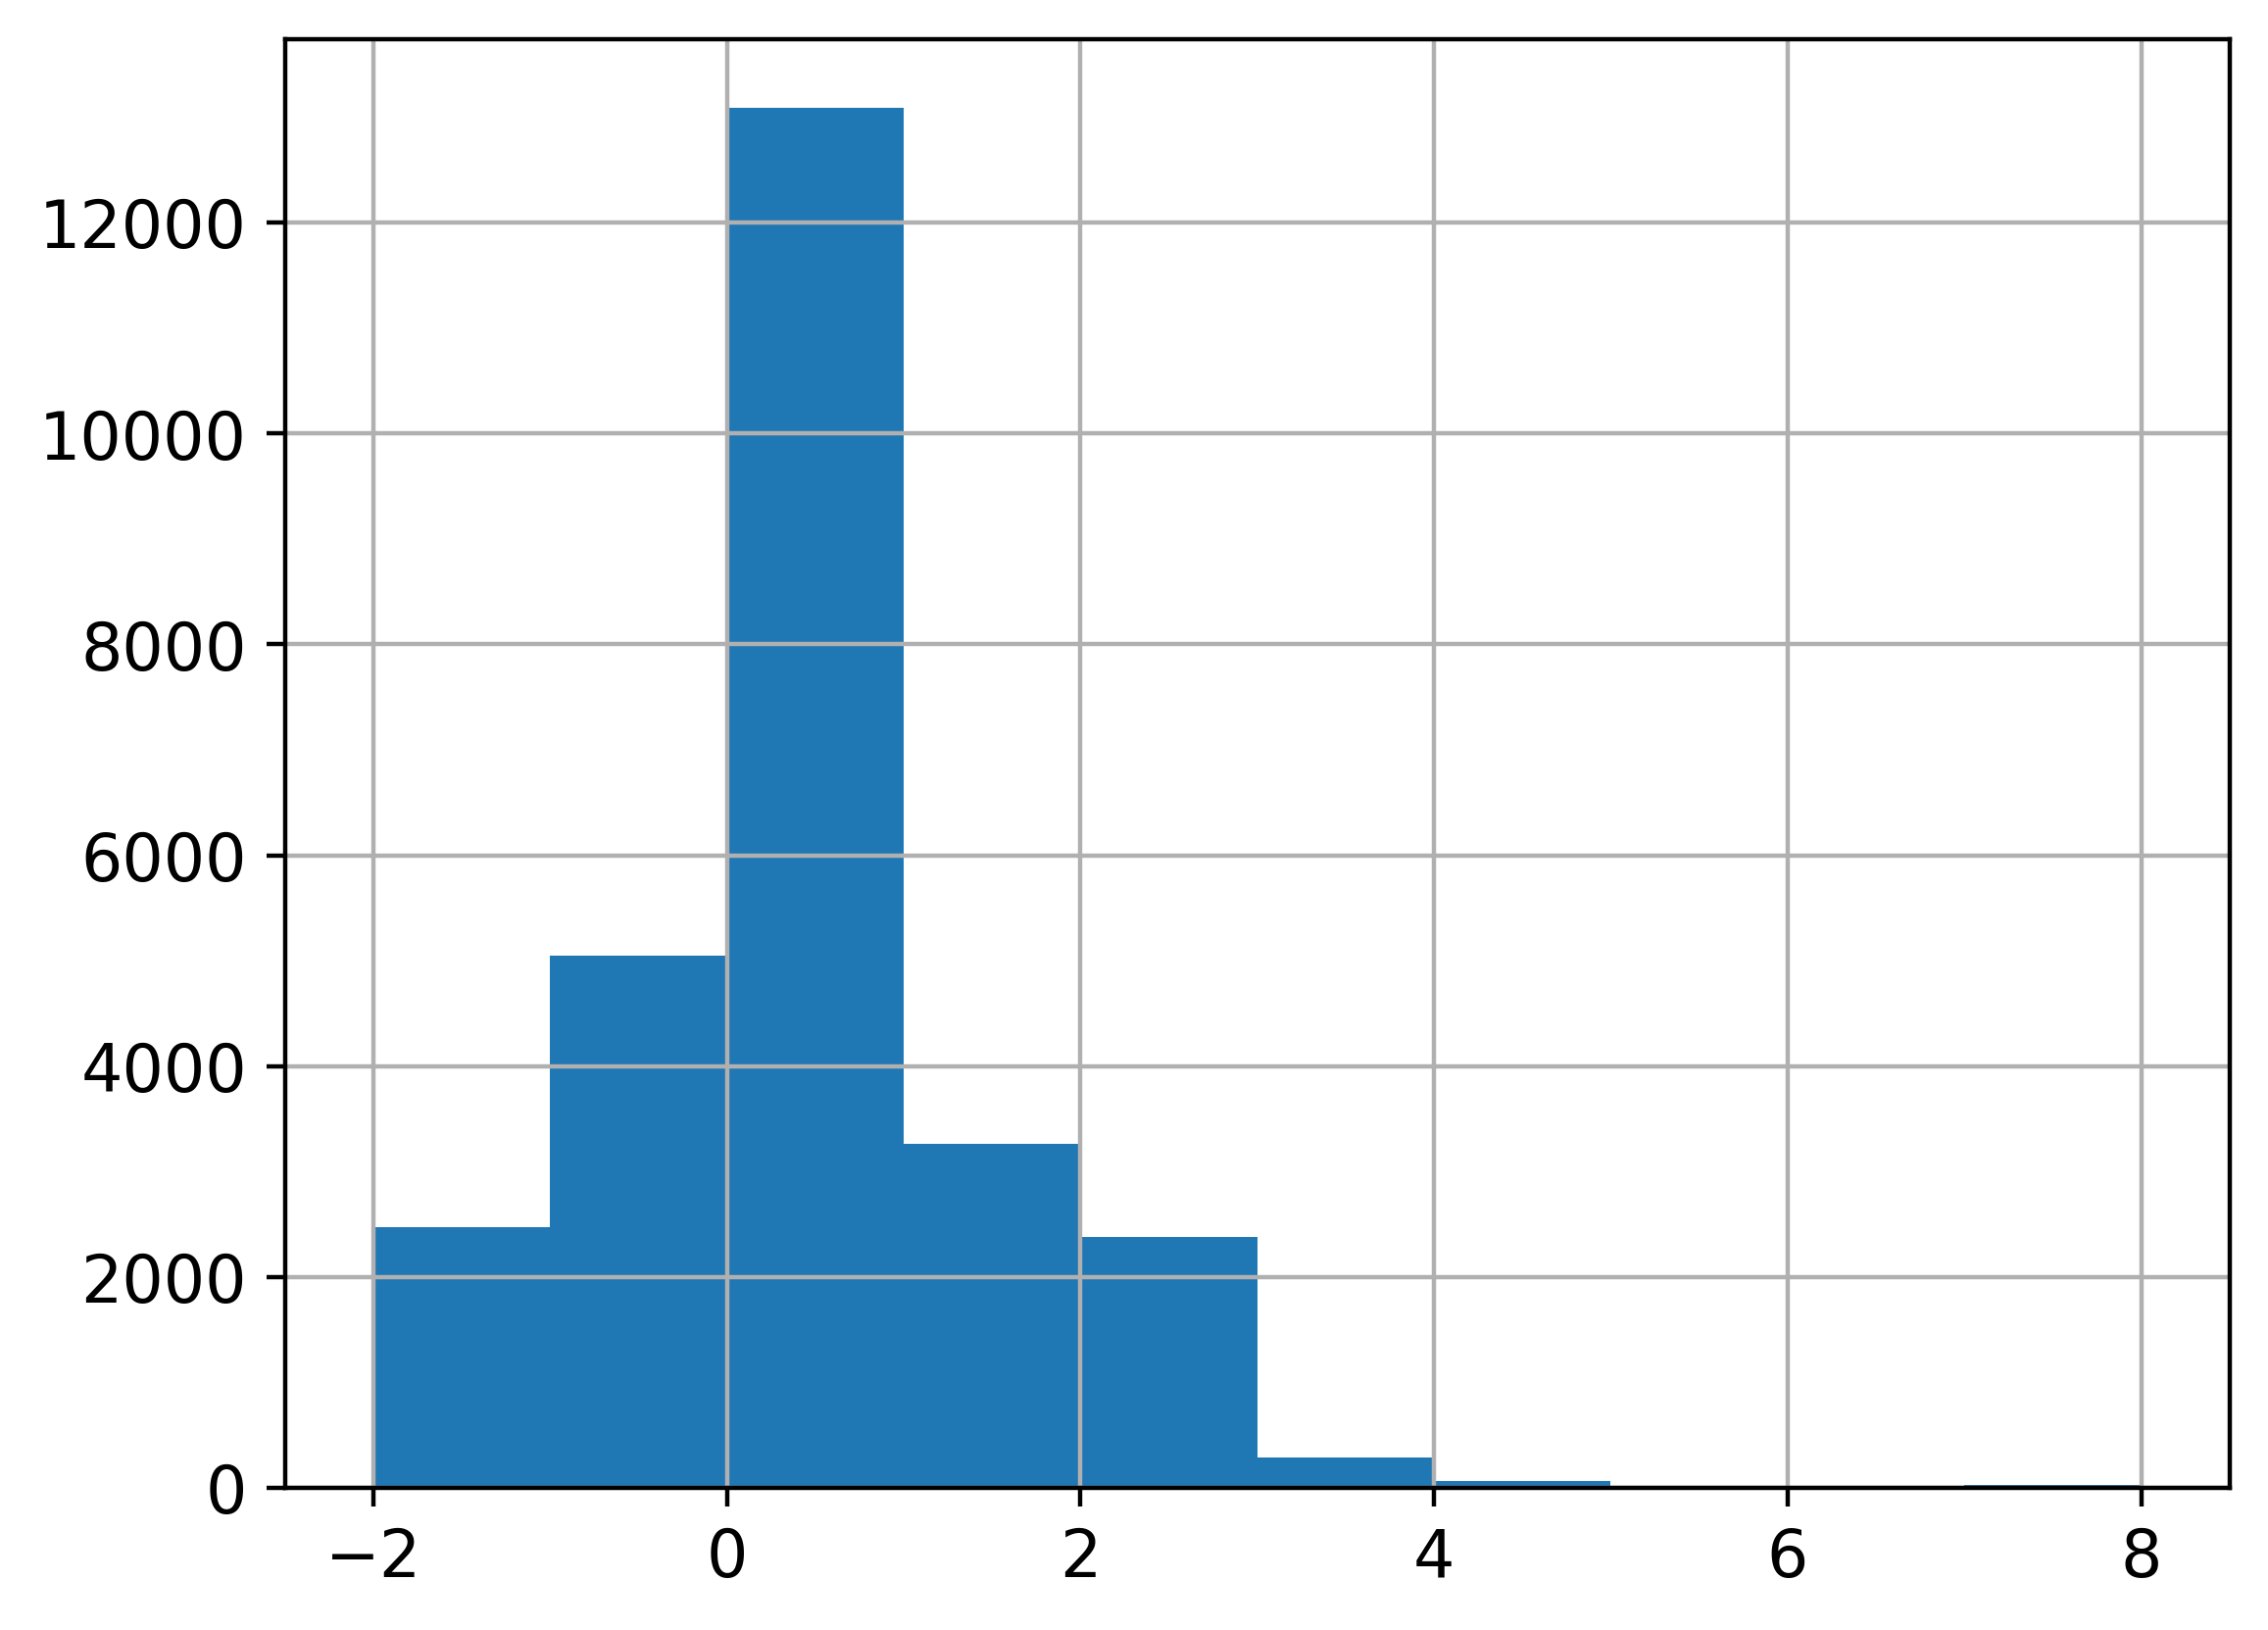

In [65]:
#Iremos exibir estes dados em um gráfico
mpl.rcParams['figure.dpi'] = 400
mpl.rcParams['font.size'] = 12
df[pay_feats[0]].hist()

A maioria dos valores são -2, -1 e 0 que correspondem a uma conta com boa situação no mês passado totalmente paga ou com pelo menos o pagamento mínimo.

In [66]:
pay_1_bins = np.array(range(-2,10)) - 0.5
pay_1_bins

array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,
        8.5])

Text(0, 0.5, 'Number of accounts')

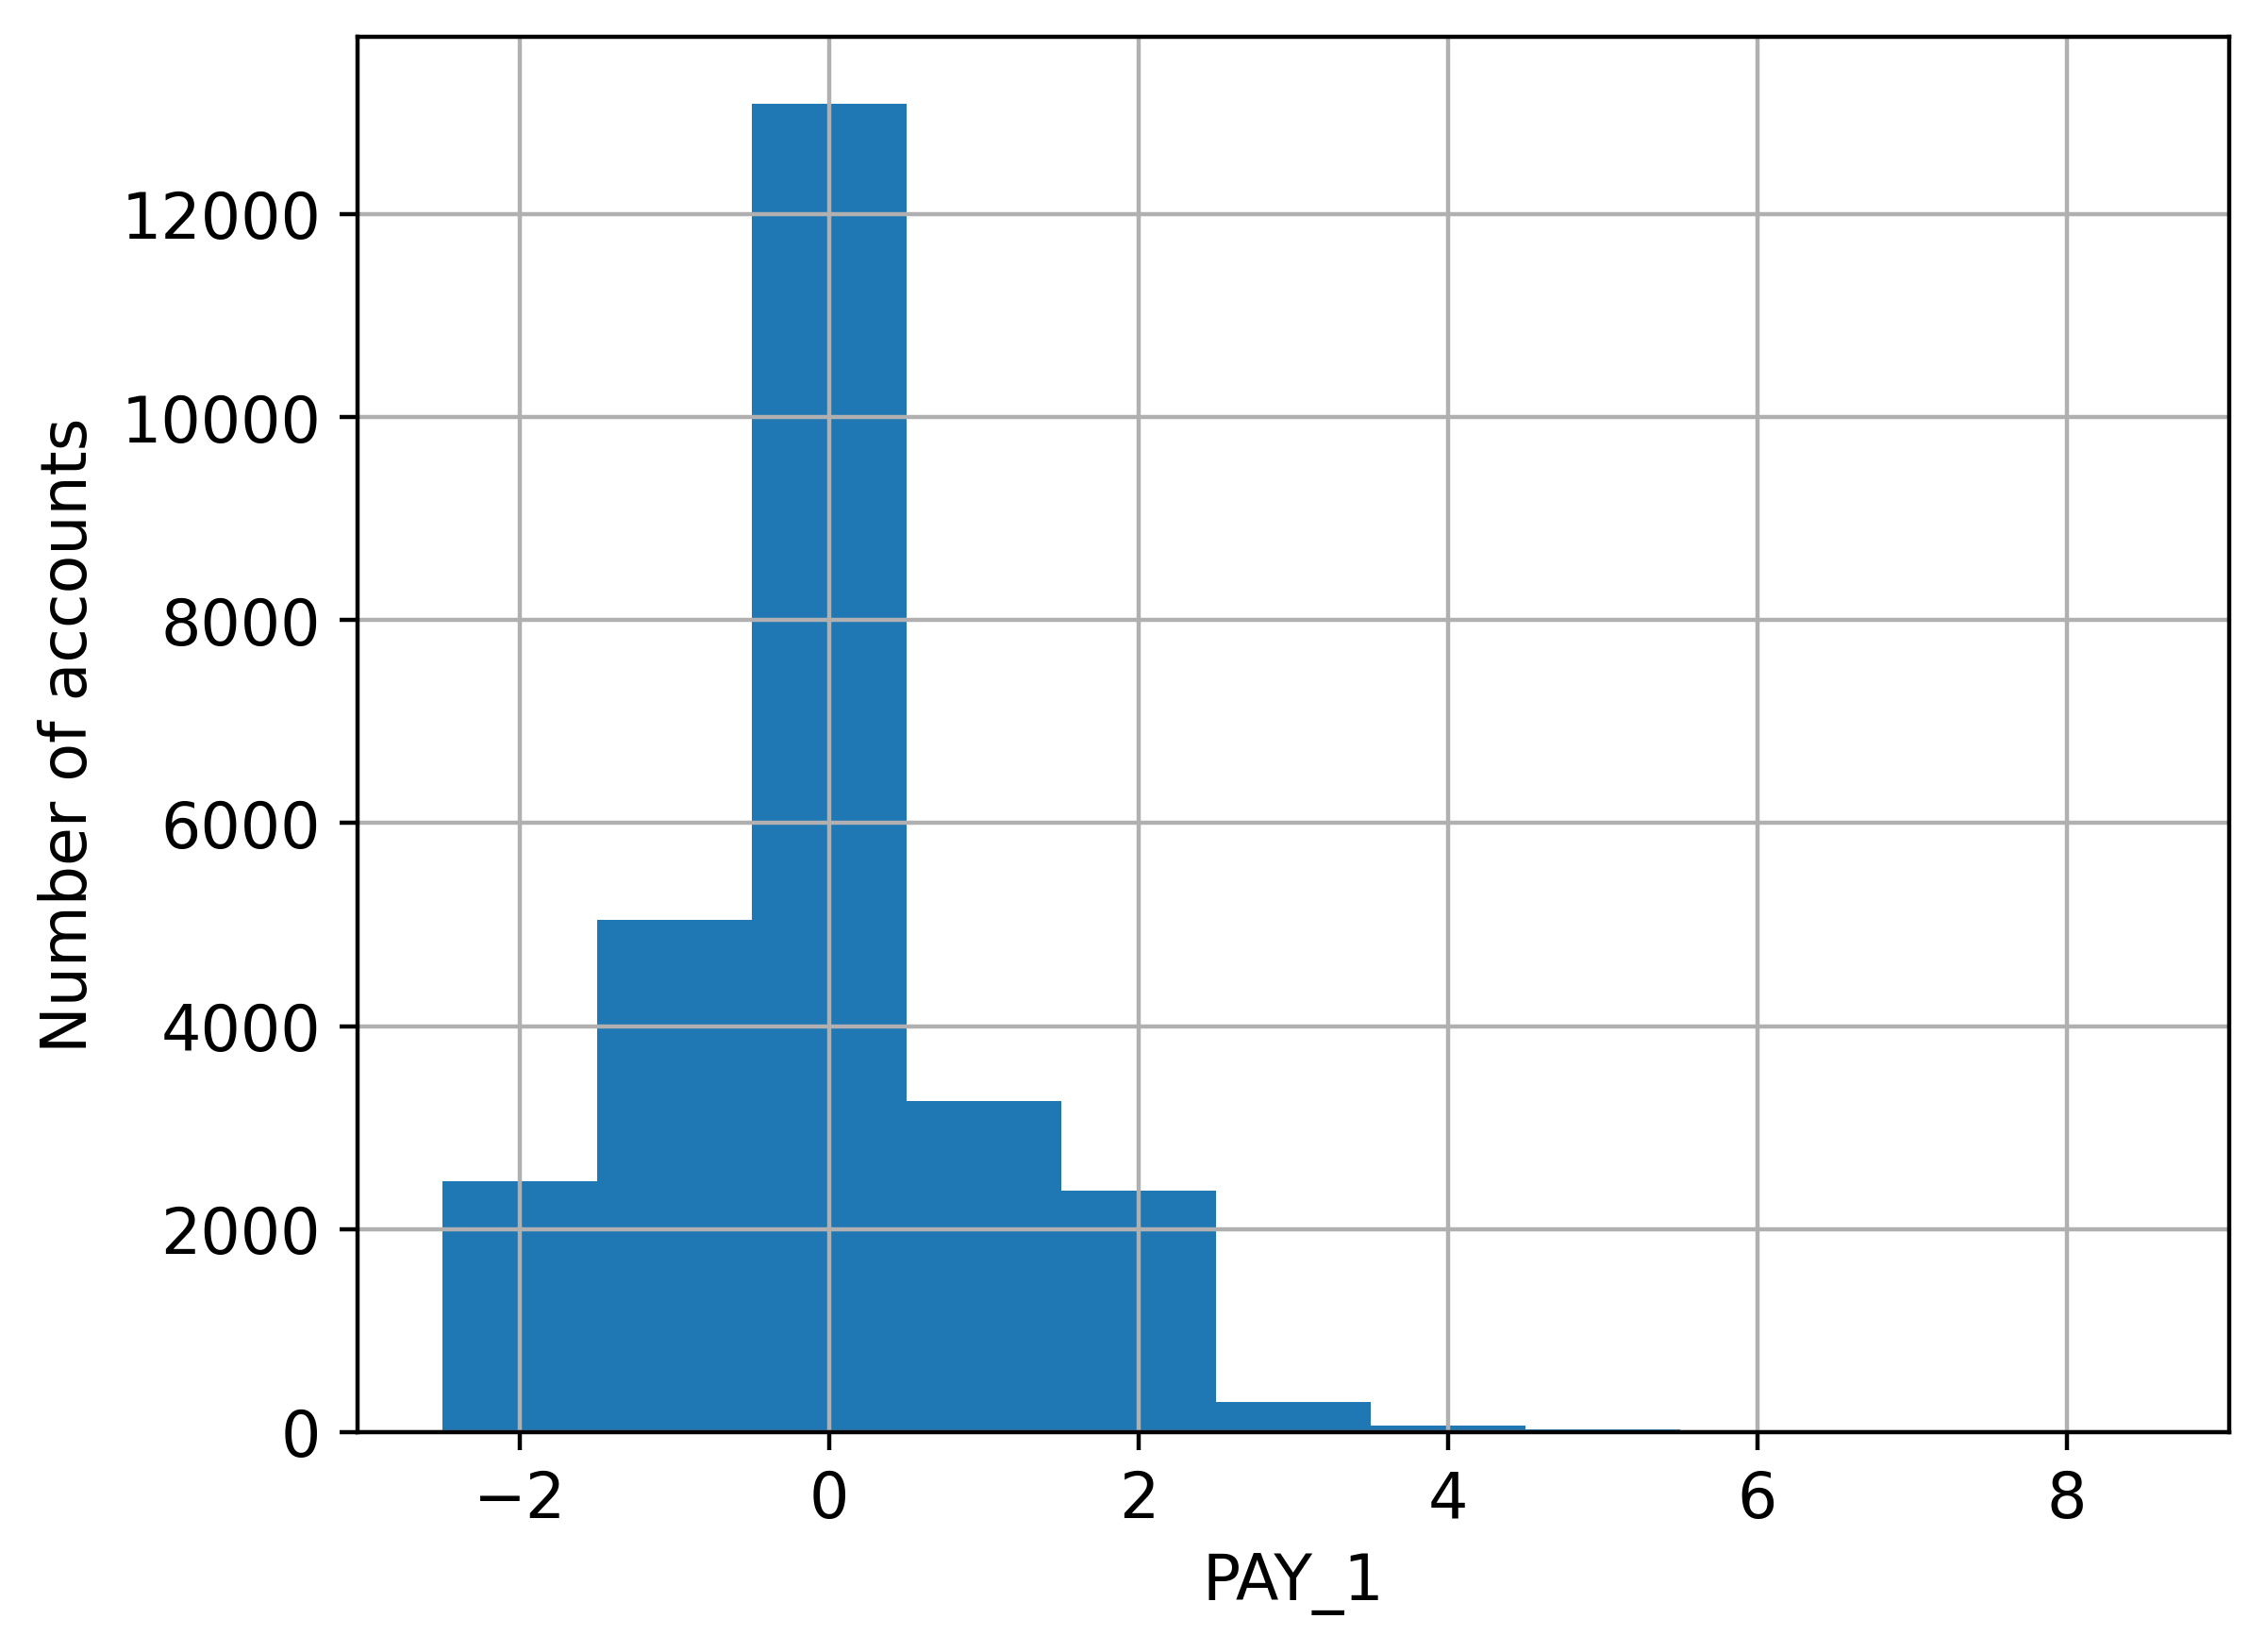

In [67]:
df[pay_feats[0]].hist(bins=pay_1_bins)
plt.xlabel('PAY_1')
plt.ylabel('Number of accounts')

In [68]:
for feat in pay_feats:
    print(df[feat].value_counts().sort_index())

PAY_1
-2     2476
-1     5047
 0    13087
 1     3261
 2     2378
 3      292
 4       63
 5       23
 6       11
 7        9
 8       17
Name: count, dtype: int64
PAY_2
-2     3375
-1     5368
 0    13961
 1       24
 2     3509
 3      289
 4       85
 5       24
 6       11
 7       17
 8        1
Name: count, dtype: int64
PAY_3
-2     3654
-1     5290
 0    13968
 1        3
 2     3400
 3      214
 4       69
 5       20
 6       19
 7       24
 8        3
Name: count, dtype: int64
PAY_4
-2     3893
-1     5070
 0    14596
 1        2
 2     2798
 3      161
 4       57
 5       30
 6        4
 7       51
 8        2
Name: count, dtype: int64
PAY_5
-2     4056
-1     4949
 0    15032
 2     2335
 3      151
 4       71
 5       14
 6        2
 7       53
 8        1
Name: count, dtype: int64
PAY_6
-2     4366
-1     5138
 0    14416
 2     2476
 3      156
 4       43
 5       10
 6       15
 7       42
 8        2
Name: count, dtype: int64


array([[<Axes: title={'center': 'PAY_1'}>,
        <Axes: title={'center': 'PAY_2'}>,
        <Axes: title={'center': 'PAY_3'}>],
       [<Axes: title={'center': 'PAY_4'}>,
        <Axes: title={'center': 'PAY_5'}>,
        <Axes: title={'center': 'PAY_6'}>]], dtype=object)

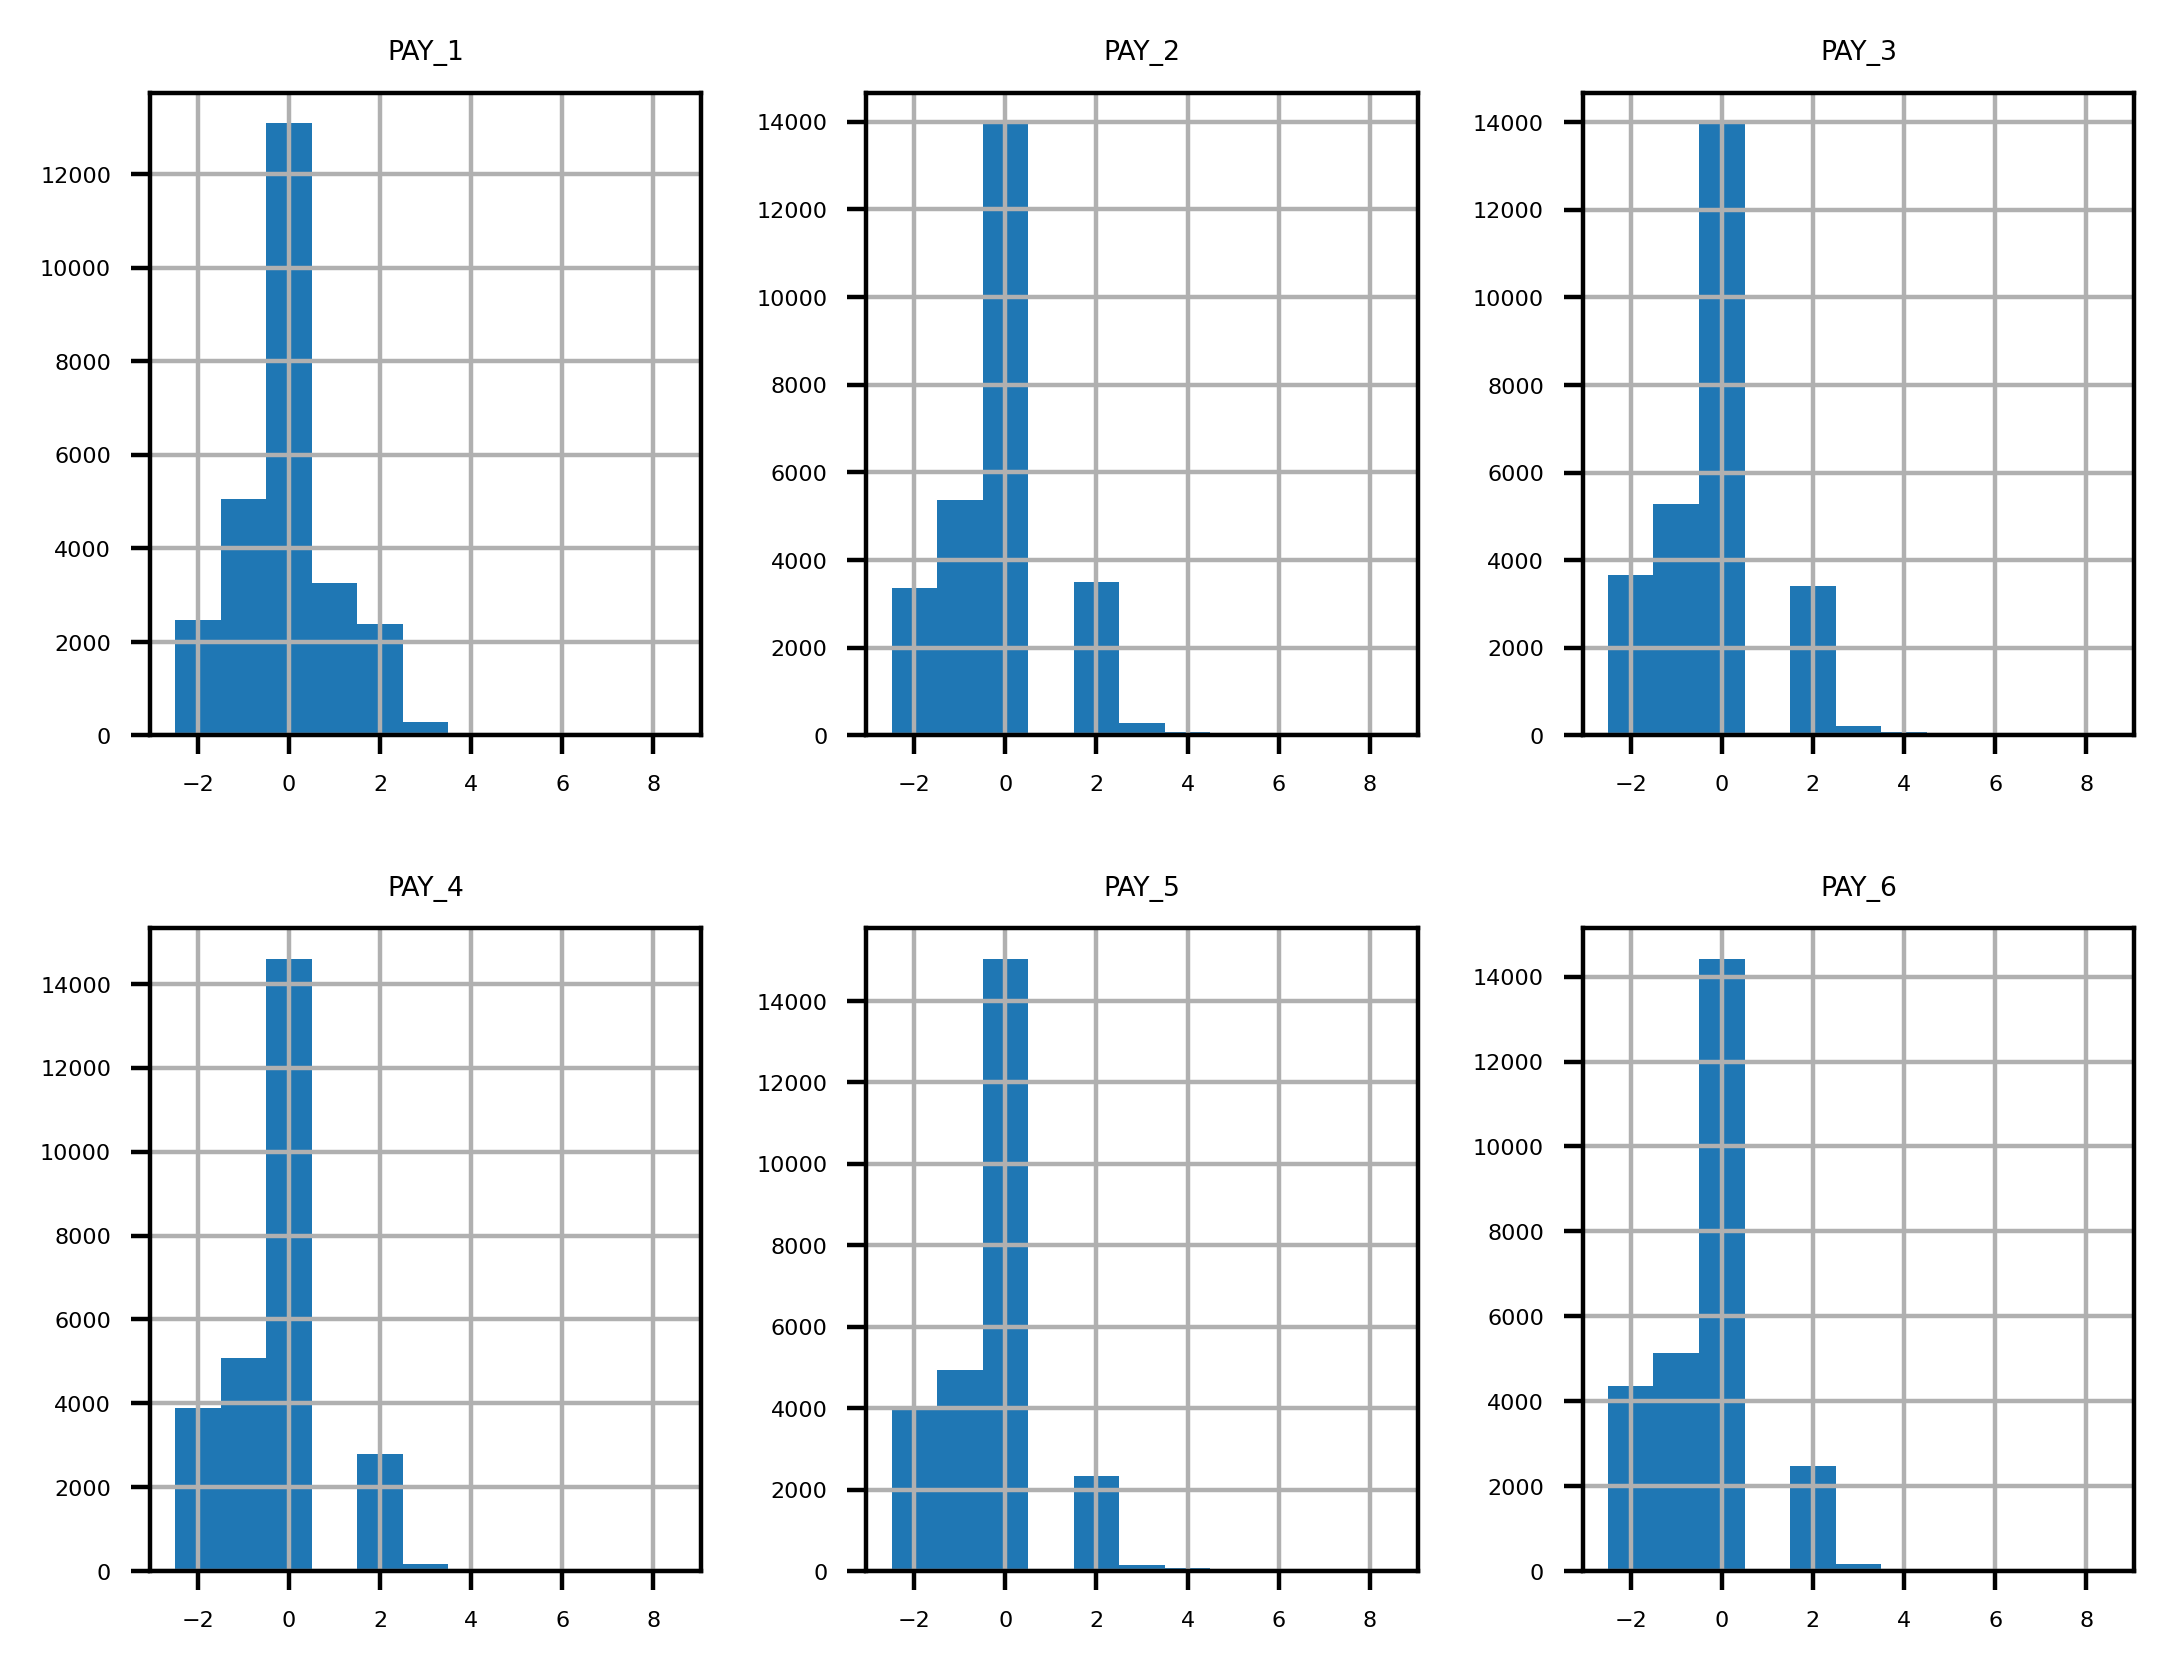

In [69]:
mpl.rcParams['font.size'] = 4
df[pay_feats].hist(bins=pay_1_bins, layout=(2,3))

In [70]:
df.loc[df['PAY_2']==2, ['PAY_2', 'PAY_3']].head()

,PAY_2,PAY_3
0,2,-1
1,2,0
13,2,2
15,2,0
50,2,2


# Atividade 1: Explorando as características financeiras restantes do dataset

In [71]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'EDUCATION_CAT', 'graduate school',
       'high school', 'others', 'university'],
      dtype='str')

As colunas restantes são BILL_AMT1 a BILL_AMT6 e PAY_AMT1 a PAY_AMT6

In [72]:
bill_feats = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_feats = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [73]:
 df[bill_feats].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,51405.730723,49300.001500,47026.340047,43338.894539,40338.136701,38889.872337
std,73633.687106,70934.549534,68705.359524,64275.250740,60705.944083,59432.541657
min,-165580.000000,-69777.000000,-157264.000000,-170000.000000,-81334.000000,-339603.000000
25%,3580.000000,2999.750000,2627.250000,2341.750000,1745.000000,1256.000000
50%,22361.000000,21150.000000,20079.500000,19037.000000,18066.000000,17005.000000
75%,67649.750000,64395.500000,60360.000000,54727.500000,50290.500000,49253.750000
max,746814.000000,671563.000000,855086.000000,706864.000000,823540.000000,699944.000000


array([[<Axes: title={'center': 'BILL_AMT1'}>,
        <Axes: title={'center': 'BILL_AMT2'}>,
        <Axes: title={'center': 'BILL_AMT3'}>],
       [<Axes: title={'center': 'BILL_AMT4'}>,
        <Axes: title={'center': 'BILL_AMT5'}>,
        <Axes: title={'center': 'BILL_AMT6'}>]], dtype=object)

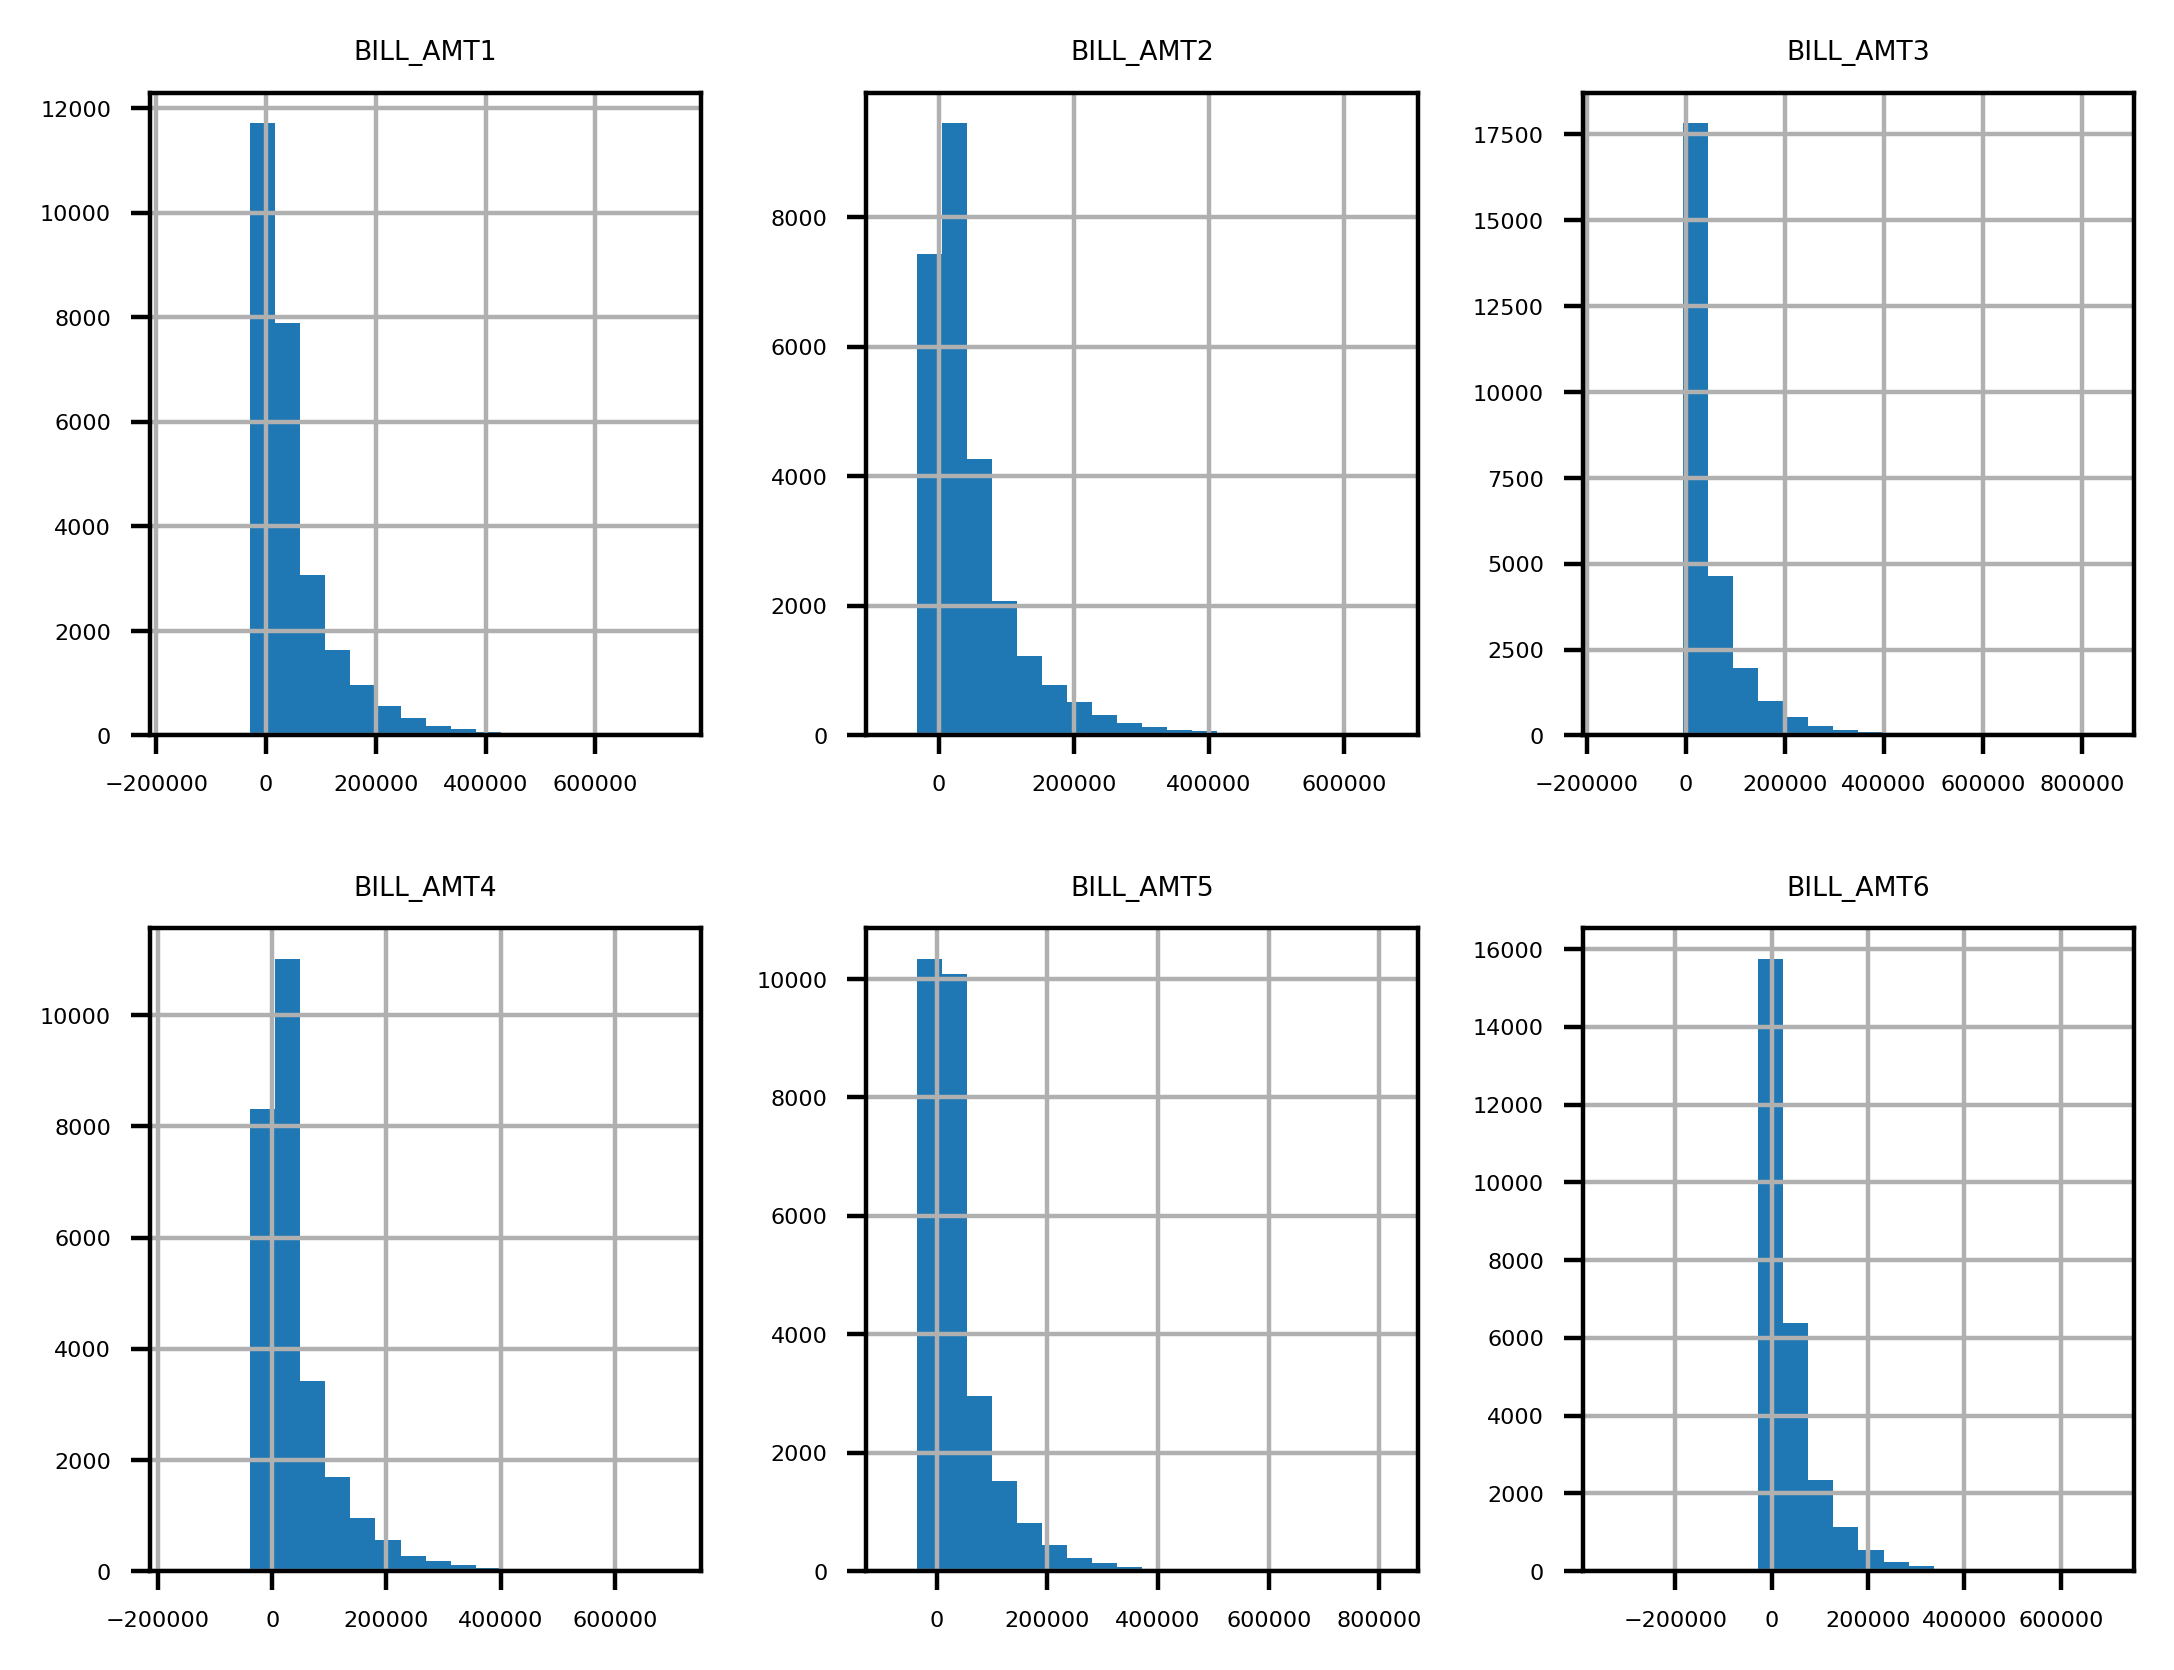

In [74]:
df[bill_feats].hist(bins=20, layout=(2,3))

In [75]:
df[pay_amt_feats].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,26664.000000,2.666400e+04,26664.000000,26664.000000,26664.000000,26664.000000
mean,5704.085771,5.881110e+03,5259.514964,4887.048717,4843.729973,5257.843047
std,16699.398632,2.121431e+04,17265.439561,15956.349371,15311.721795,17635.468185
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1000.000000,8.020000e+02,390.000000,294.750000,242.750000,111.000000
50%,2114.500000,2.007000e+03,1822.000000,1500.000000,1500.000000,1500.000000
75%,5027.000000,5.000000e+03,4556.250000,4050.500000,4082.750000,4015.000000
max,873552.000000,1.227082e+06,889043.000000,621000.000000,426529.000000,528666.000000


array([[<Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>,
        <Axes: title={'center': 'PAY_AMT3'}>],
       [<Axes: title={'center': 'PAY_AMT4'}>,
        <Axes: title={'center': 'PAY_AMT5'}>,
        <Axes: title={'center': 'PAY_AMT6'}>]], dtype=object)

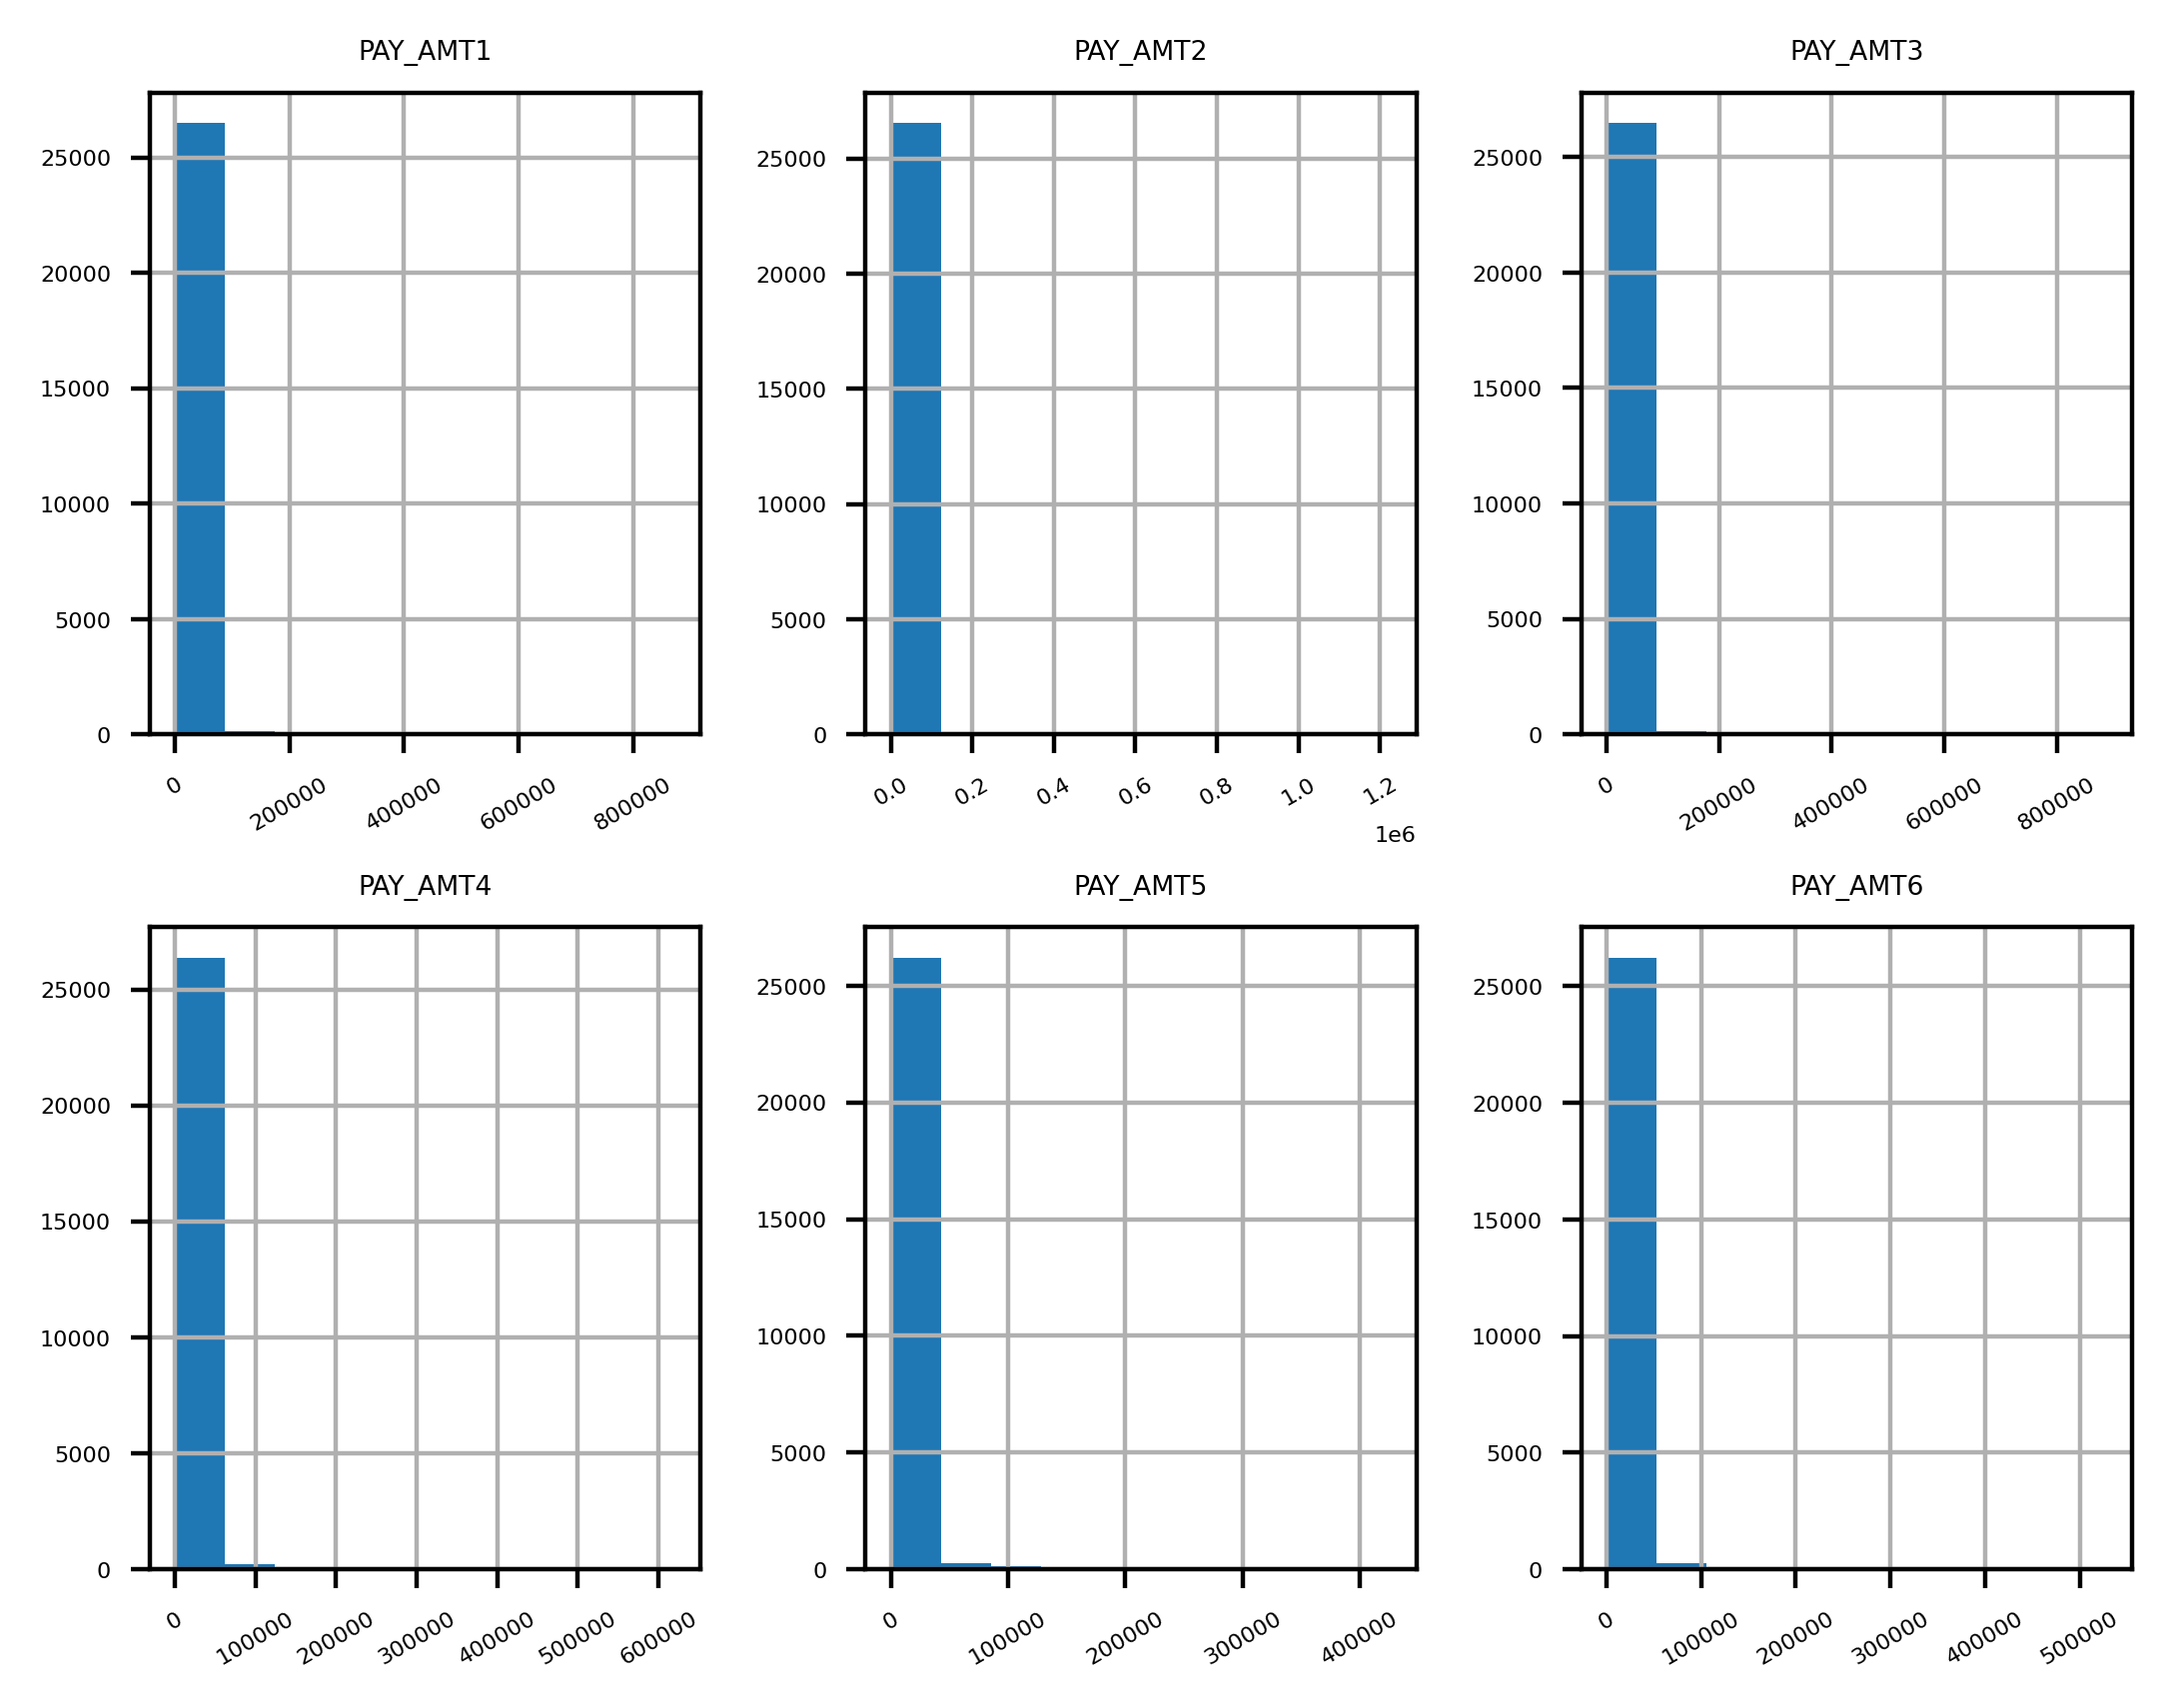

In [76]:
df[pay_amt_feats].hist(layout=(2,3), xrot=30)

In [77]:
pay_zero_mask = df[pay_amt_feats] == 0

In [78]:
pay_zero_mask.head()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,True,False,True,True,True,True
1,True,False,False,False,True,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False


In [79]:
pay_zero_mask.sum()

PAY_AMT1    4656
PAY_AMT2    4833
PAY_AMT3    5293
PAY_AMT4    5697
PAY_AMT5    5981
PAY_AMT6    6373
dtype: int64

array([[<Axes: title={'center': 'PAY_AMT1'}>,
        <Axes: title={'center': 'PAY_AMT2'}>,
        <Axes: title={'center': 'PAY_AMT3'}>],
       [<Axes: title={'center': 'PAY_AMT4'}>,
        <Axes: title={'center': 'PAY_AMT5'}>,
        <Axes: title={'center': 'PAY_AMT6'}>]], dtype=object)

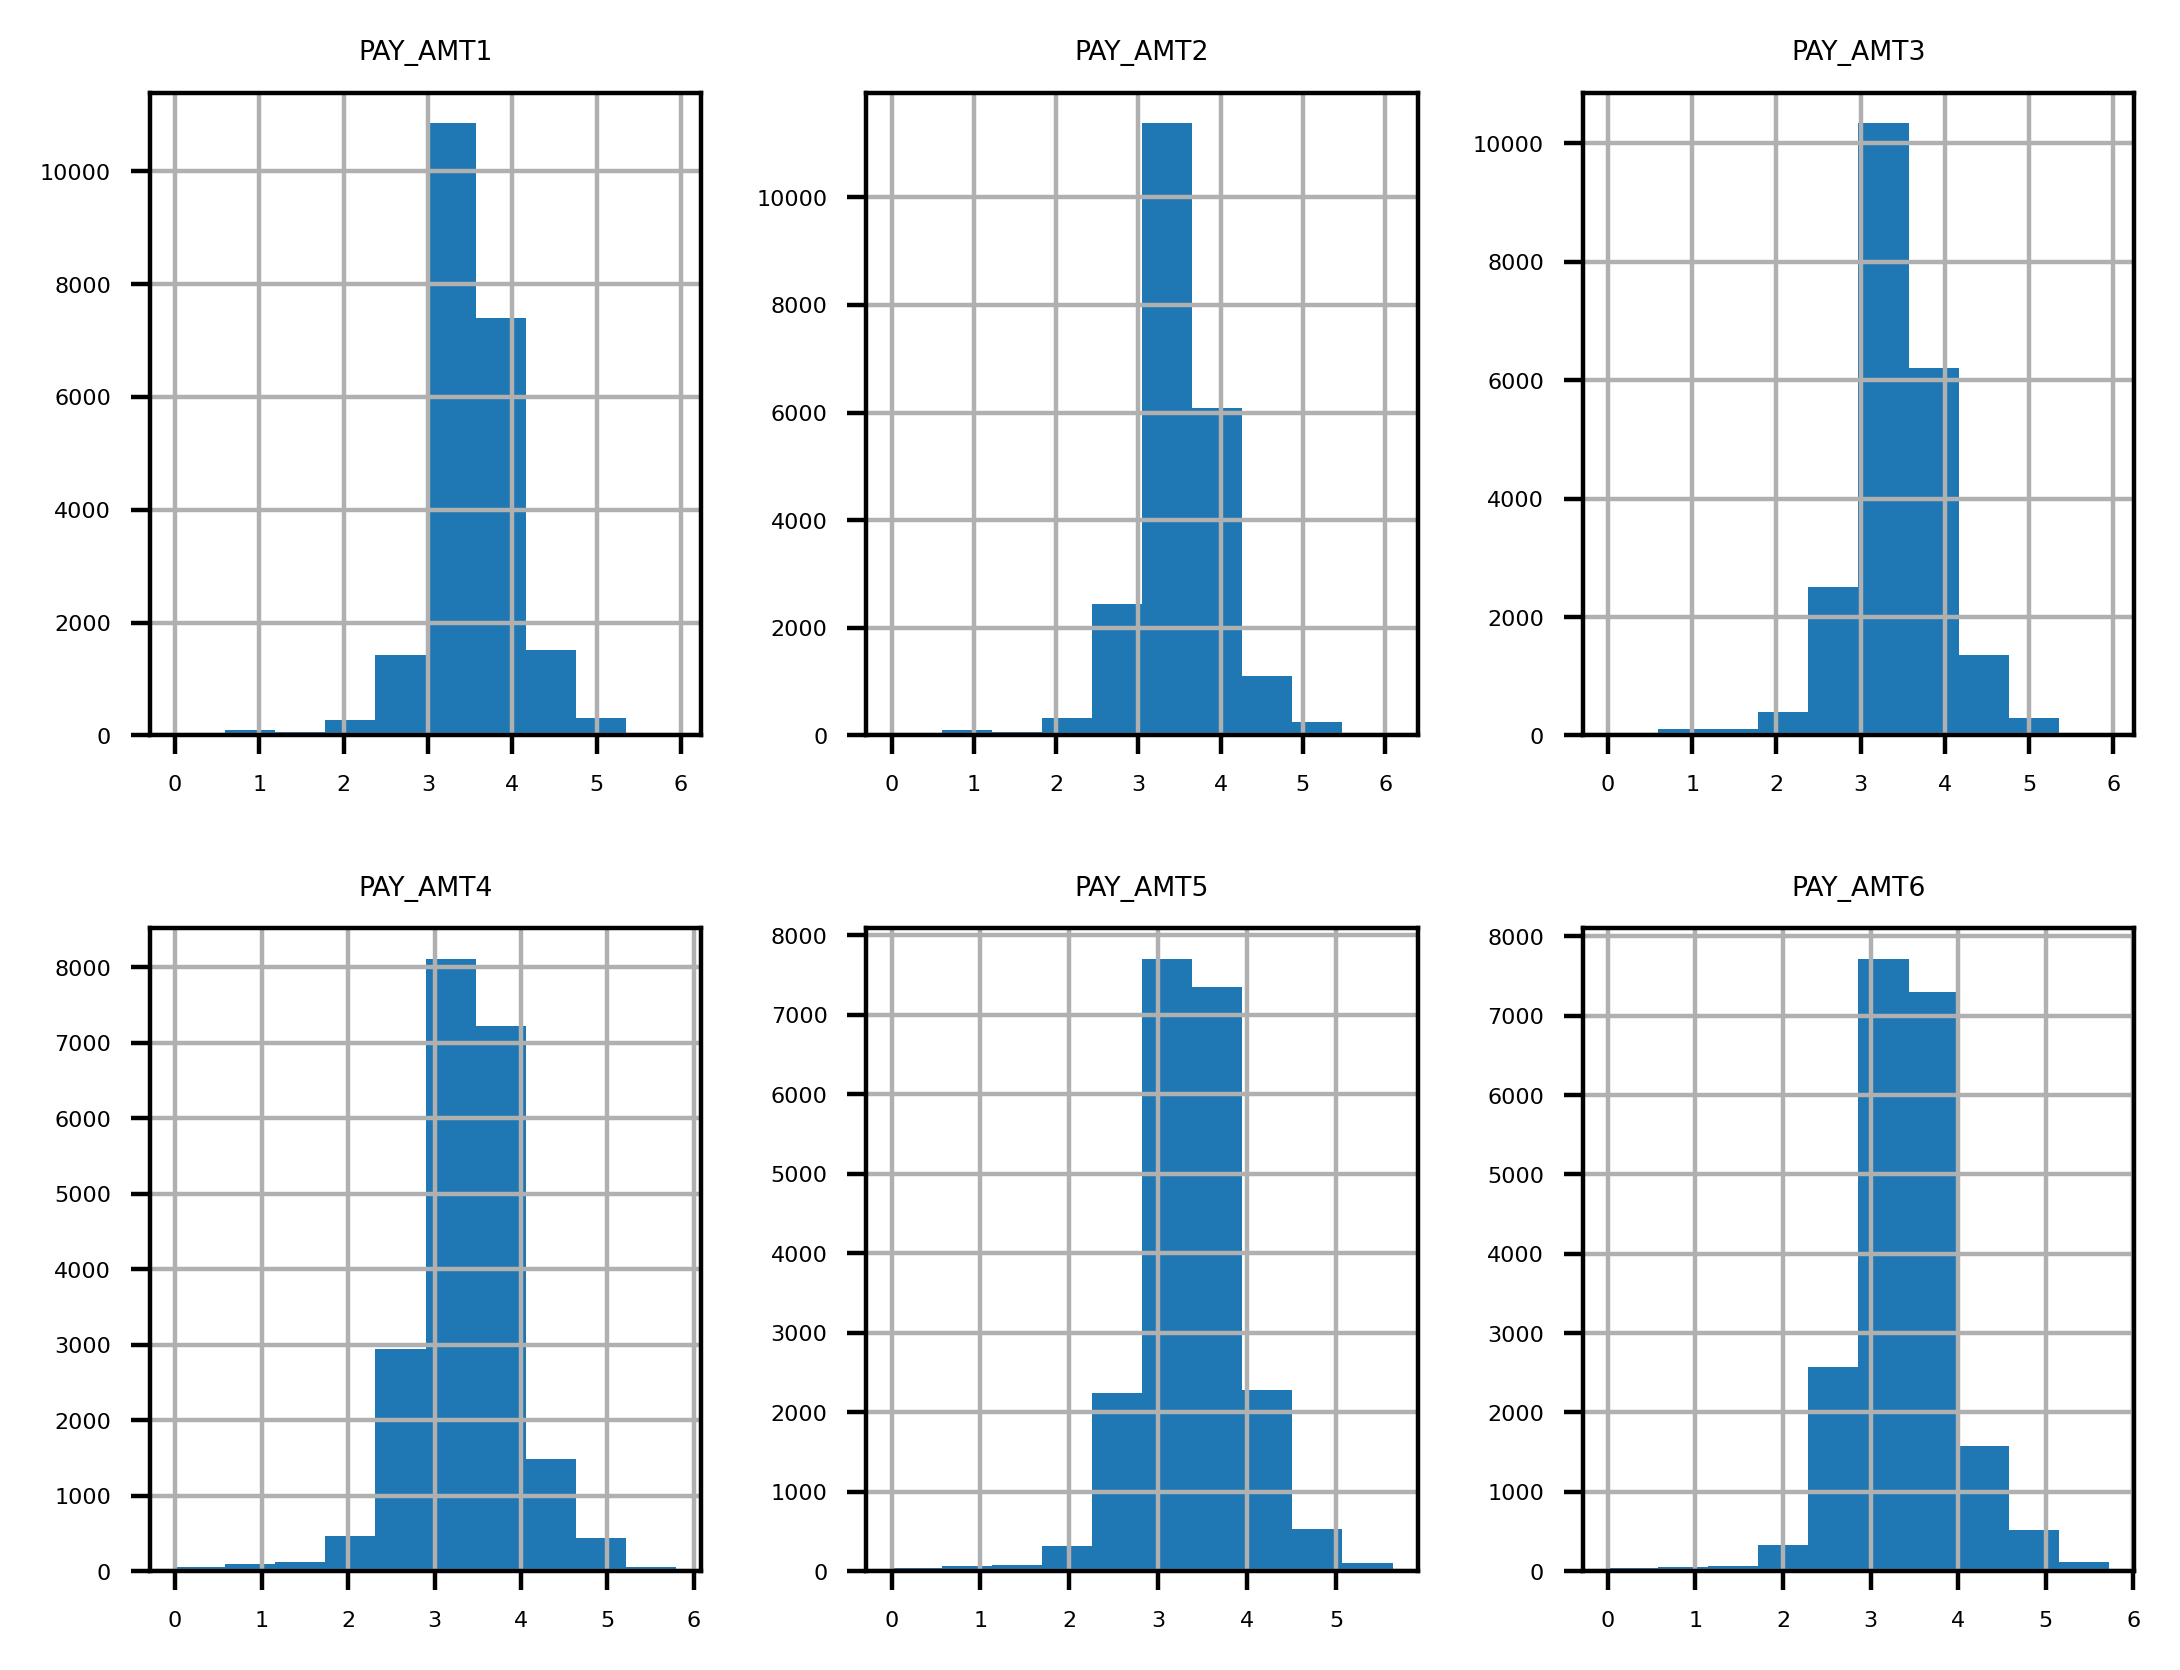

In [80]:
df[pay_amt_feats][~pay_zero_mask].apply(np.log10).hist(layout=(2,3))